In [11]:
import numpy as np 
import matplotlib.pyplot as plt 
import mc

In [20]:
# We first define the constants
p_1 = 1/np.sqrt(2)
p_2 = 0
p_3 = 0.7
N = 200
iteration_count = 4000
number_deltas = 50
x, y = 0, 0

In [21]:
# computes mu_f supposing that the stationary distribution is uniform
def compute_f_average(f):
    sum = 0
    for x in range(N):
        for y in range(N):
            sum += f(x, y)
    return sum/(N**2)# defined for any general f

# forcing condition ||g - mu_g|| 
def normalize(g):
    mu_g = compute_f_average(g)
    norm = 0
    for x in range(N):
        for y in range(N):
            norm += (g(x,y) - mu_g)**2 
    norm = norm * 1/(N**2)
    return lambda x,y: (g(x,y) - mu_g)/np.sqrt(norm) 

def compute_delta(p, g, number_deltas, iteration_count):
    f = normalize(g)

    all_deltas = np.zeros((number_deltas, iteration_count))
    for j in range(number_deltas):
        # we want X_0 to be sampled from the stationary distribution, so we randomly draw initial x and y
        # this is how to simulate the stationary distribution!!!
        x = np.random.randint(0, N)
        y = np.random.randint(0, N)
        f_sum = 0
        
        for i in range(iteration_count):
            x, y = mc.take_step(x, y, p, N)
            f_sum += f(x, y)

            all_deltas[j, i] = (f_sum/(i+1))**2
    delta_n = np.sqrt(np.mean(all_deltas, axis=0))
    return delta_n

In [34]:
def dirac_1(x, y):
    if (x+y) % 7 == 0:
        return 1
    return 0

def dirac_2(x, y):
    if x == 3:
        return 1
    return 0

def sin_square(x, y):
    return np.sin(x**2 + y**2)

def dirac_3(x, y):
    if x == 100 and y == 56:
        return 5
    elif x == 67:
        return 1000
    elif x == 0 and y == 0:
        return 1000
    return 0

In [23]:
def plot_functions(functions_list, number_deltas=number_deltas, iteration_count=iteration_count):
    delta_n_list = []
    for f in functions_list:
        delta_n_f = compute_delta(p_1, f, number_deltas, iteration_count)
        plt.plot(range(iteration_count), delta_n_f, label="irrational")
        delta_n_list.append(delta_n_f)

        delta_n_f = compute_delta(p_3, f, number_deltas, iteration_count)
        plt.plot(range(iteration_count), delta_n_f, label="rational")
        delta_n_list.append(delta_n_f)
    plt.legend()
    return delta_n_list

Text(0.5, 1.0, 'sin(x^2 + y^2) plot')

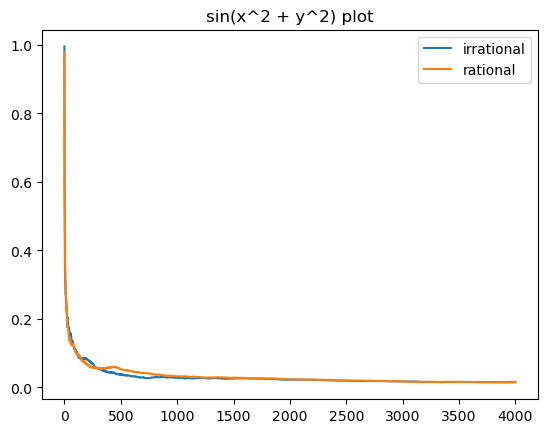

In [24]:
# test sin_squared
functions_test = [sin_square]
sin_delta = plot_functions(functions_test)

plt.title("sin(x^2 + y^2) plot")

In [25]:
tau_rational = mc.compute_tau(sin_delta[0])
tau_irrational = mc.compute_tau(sin_delta[1])
print("*** function: f(x,y) = sin(x^2 + y^2) ***")
print("Irrational tau: ", tau_rational)
print("Rrational tau: ", tau_irrational)

*** function: f(x,y) = sin(x^2 + y^2) ***
Irrational tau:  0.34940334086219843
Rrational tau:  0.40800855173034883


Text(0.5, 1.0, '1_{x+y mod 7}')

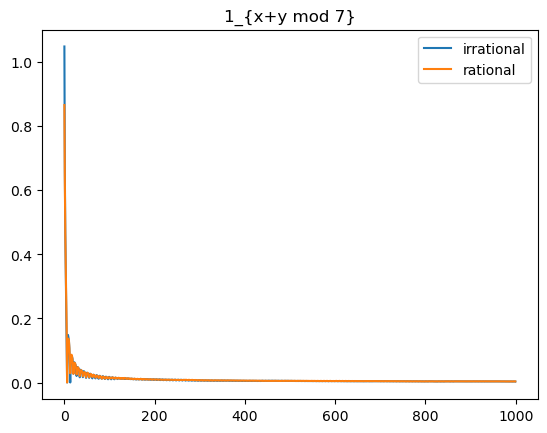

In [26]:
test_dirac = [dirac_1]
dirac_1_delta = plot_functions(test_dirac, iteration_count=1000)
plt.title("1_{x+y mod 7}")

In [27]:
tau_rational = mc.compute_tau(dirac_1_delta[0])
tau_irrational = mc.compute_tau(dirac_1_delta[1])
print("*** function: f(x,y) = 1_{x+y mod 7} ***")
print("Irrational tau: ", tau_rational)
print("Rrational tau: ", tau_irrational)

*** function: f(x,y) = 1_{x+y mod 7} ***
Irrational tau:  0.10927725388510182
Rrational tau:  0.10668067441195027


[array([0.07106778, 0.99247135, 0.6603911 , ..., 0.02382975, 0.02377553,
        0.02372111]),
 array([0.07106778, 0.07106778, 0.07106778, ..., 0.01956948, 0.0195677 ,
        0.01956593])]

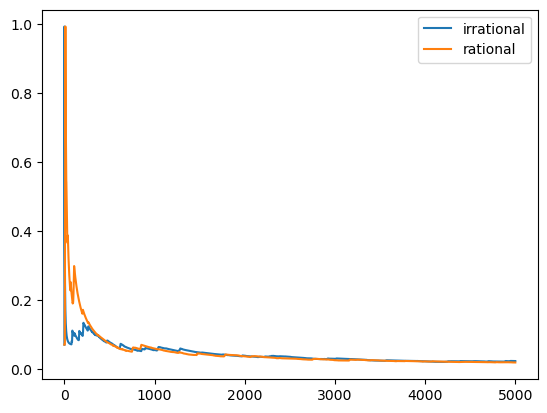

In [37]:
plot_functions([dirac_3], iteration_count=5000)